# 05 拐角光顺

本节看一条 G01 微线段刀路（短线段串成的折线）为什么走不快，以及局部拐角光顺（corner smoothing）
怎么把它跑起来。完整的流水线就是库的主流程：刀路 → 前瞻 → 速度规划 → 插补 → 评价。

## 本节要回答的问题

- G01 微线段刀路为什么走不快？转角与进给上限是什么关系？
- 局部拐角光顺做了什么？"逼近误差"由哪个量控制？
- Hermite 过渡的误差公式 $\varepsilon = \tfrac38\ell\sin(\varphi/2)$ 怎么验证？
- 光顺后的 block 如何划分？连接点为什么放在过渡中点？
- G01、Hermite 过渡、Zhao 2013、Xu 2018 四种方法效果差多少？

## 前置知识

- `notebooks/01_曲线与导数栈.ipynb`：导数栈的形状约定 $(4, ..., d)$；
- 弧长参数化与曲率：曲率峰值处的几何限速（弓高误差、法向加速度、法向 jerk）；
- 前瞻与速度规划：刀路分成 block，连接点是速度控制点，block 内生成 S 曲线。

In [1]:
import os.path as osp
import sys
from pathlib import Path

import matplotlib.pyplot as plt

root_path = Path(osp.abspath("")).parents[0]
sys.path.append(str(root_path))

%config InlineBackend.figure_format='retina'

In [2]:
import numpy as np

import cnc5x as cx
from cnc5x import plotting

plotting.use_style()

## 1. G01 为什么走不快：拐角处的限速

平面轮廓用一串串 G01 微线段逼近，但在拐角（corner）处刀尖的速度方向必须改变。
连续插补给出的可行上界是：一个插补周期 $T_s$ 内速度矢量的变化不能超过 $a_{\max}T_s$
（Zhao et al. 2013 采用的模型）。速度大小为 $v$、方向转过转角（turning angle）$\varphi = 2\beta$
时，速度矢量的变化量是 $2v\sin\beta$，所以

$$
2v\sin\beta \le a_{\max}T_s,
\qquad\text{即}\qquad
v \le \frac{a_{\max}T_s}{2\sin\beta}.
$$

先看最小的例子 rhombic：菱形轮廓，3 个 $90^\circ$ 拐角。取教材常用参数
$V=100$ mm/s、$A=3000$ mm/s²、$J=60000$ mm/s³、$T_s=0.5$ ms（与
`examples/corner_smoothing.py` 相同）。

In [3]:
V_MAX, A_MAX, J_MAX, TS = 100.0, 3000.0, 60000.0, 0.0005  # mm/s、mm/s²、mm/s³、s
TOL = 0.02  # 拐角逼近误差上限，mm

pts_r = cx.datasets.load_dataset("rhombic").points
linear_r = cx.LinearPath(pts_r)
v_limit = linear_r.get_v_limit(TS, V_MAX, A_MAX, J_MAX)
print("rhombic 各连接点限速 (mm/s):", np.round(v_limit, 4))
print("拐角限速 (公式):", A_MAX * TS / (2 * np.sin(np.deg2rad(45))))
assert np.allclose(v_limit[1], A_MAX * TS / (2 * np.sin(np.deg2rad(45))))
print("边长 (mm):", np.round(np.linalg.norm(np.diff(pts_r, axis=0), axis=1), 3))
for path_r in (linear_r, cx.HermiteCornerPath(pts_r, TOL, TOL)):
    profile_r, _, _ = cx.schedule(path_r, V_MAX, A_MAX, J_MAX, TS)
    print(f"{type(path_r).__name__:18s} 用时 {profile_r.duration:.3f} s")

rhombic 各连接点限速 (mm/s): [0.     1.0607 1.0607 1.0607 0.    ]
拐角限速 (公式): 1.0606601717798214
边长 (mm): [2.828 2.828 2.828 2.828]
LinearPath         用时 0.454 s
HermiteCornerPath  用时 0.438 s


每个 $90^\circ$ 拐角的限速约 1.06 mm/s，只有巡航进给的 1/94，基本就是停车再起步。
不过菱形每边只有 2.83 mm，S 曲线在这么短的距离里本来也加不到多快，所以光顺在这里省不了多少时间
（上面打印的两个用时只差约 3%）。拐角光顺的收益要在长边多、拐角密的轮廓上才看得出来。

再看更接近工程实际的 butterfly 轮廓（100 点、98 个拐角，转角从不到 $0.02^\circ$ 到约 $168^\circ$）。
两张图都把限速画在转角轴上：左图纵轴是线性的，右图纵轴取对数，虚线就是上面的公式本身。

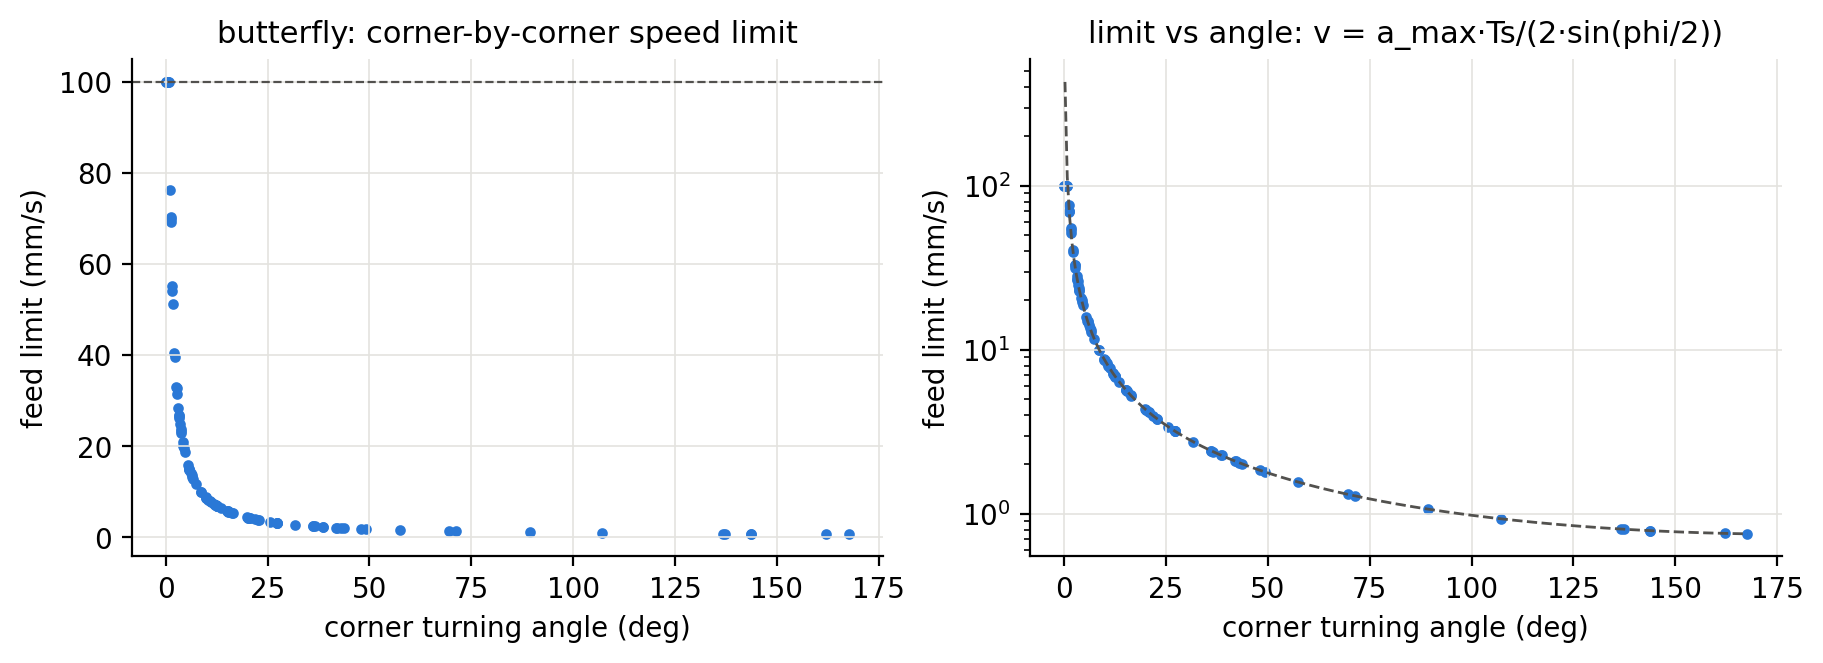

In [4]:
pts_bf = cx.datasets.load_dataset("butterfly").points
linear_bf = cx.LinearPath(pts_bf)
v_bf = linear_bf.get_v_limit(TS, V_MAX, A_MAX, J_MAX)[1:-1]
phi = linear_bf.turning_angles

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
axes[0].scatter(np.degrees(phi), v_bf, s=8, color=plotting.COLORS[0])
axes[0].axhline(V_MAX, color=plotting.LIMIT, ls="--", lw=0.8)
axes[0].set(
    xlabel="corner turning angle (deg)", ylabel="feed limit (mm/s)", title="butterfly: corner-by-corner speed limit"
)
angles = np.linspace(0.2, np.degrees(phi).max(), 300)
axes[1].plot(angles, A_MAX * TS / (2 * np.sin(np.radians(angles) / 2)), color=plotting.LIMIT, ls="--", lw=1.0)
axes[1].scatter(np.degrees(phi), np.minimum(v_bf, V_MAX), s=8, color=plotting.COLORS[0])
axes[1].set(
    xlabel="corner turning angle (deg)",
    ylabel="feed limit (mm/s)",
    yscale="log",
    title="limit vs angle: v = a_max·Ts/(2·sin(phi/2))",
)
plt.show()

In [5]:
near_stop = (v_bf < 5.0).sum()
print(
    f"butterfly 98 个拐角：限速 < 5 mm/s 的有 {near_stop} 处，"
    f"< 1 mm/s 的有 {(v_bf < 1.0).sum()} 处，最低 {v_bf.min():.3f} mm/s"
)
assert near_stop > 0 and v_bf.min() < 1.0

butterfly 98 个拐角：限速 < 5 mm/s 的有 36 处，< 1 mm/s 的有 7 处，最低 0.754 mm/s


右图里所有点都落在虚线上，只有近直行的几个拐角被 $v_{\max}$ 截掉。$\sin\beta$ 在 $[0, 90^\circ]$
上单调增，所以转角越大限速越低；转角趋于 $180^\circ$（掉头）时，限速降到最低值 $a_{\max}T_s/2 = 0.75$ mm/s。
98 个拐角里 36 个限速不到 5 mm/s，G01 走整条轮廓就是不停地加减速。

**要点**：拐角限速正比于 $1/\sin\beta$。拐角越尖、越密，G01 的平均进给就越低。

## 2. 局部拐角光顺的几何：裁一点、换一条曲线

拐角走得慢的根源是方向突变。局部拐角光顺的做法很直接：在拐角两侧各裁去长度 $\ell$，
在两个接点（join point）之间插入一条光滑的过渡曲线（transition curve），换掉硬拐角；
轨迹不再经过原顶点，偏离顶点最多 $\varepsilon$，这个值就是逼近误差（approximation error）。

库里的教学基线是 `HermiteCornerPath`：两个接点处取两侧直线对弧长的导数栈
（`corner_ends`），过渡曲线让两端直到二阶导数都与直线吻合——这是一条**五次 Hermite**
（`hermite_transition`，参数速度取 $h = 2\ell$）。对称构形下，曲线上离顶点最近的是它的中点，
距离有闭式解（`docs/数学约定.md` 第 6 节）：

$$
\varepsilon = \frac{3}{8}\,\ell\sin\frac{\varphi}{2},
\qquad\text{即}\qquad
\ell = \frac{8\varepsilon}{3\sin(\varphi/2)}.
$$

给定逼近误差容差，就可以反解该裁多少 $\ell$。下面先在几个转角上数值验证这个公式。

In [6]:
from scipy.optimize import minimize_scalar

# 独立参考：数值搜索过渡曲线上离顶点（原点）最近的点，与闭式 ε = (3/8)·ℓ·sin(φ/2) 比较
eps_cmd = 0.05  # 容差，mm
for deg in (30, 60, 90, 120, 150):
    phi = np.deg2rad(deg)
    d0 = np.array([np.cos(phi / 2), np.sin(phi / 2)])
    d1 = np.array([np.cos(phi / 2), -np.sin(phi / 2)])
    pts3 = np.array([-10.0 * d0, np.zeros(2), 10.0 * d1])  # 两条 10 mm 的边，顶点在原点
    path = cx.HermiteCornerPath(pts3, eps_cmd, eps_cmd)
    curve = path.transitions[0]
    u_coarse = np.linspace(0.0, 1.0, 201)
    dists = np.linalg.norm(curve(u_coarse), axis=-1)
    i0 = dists.argmin()
    r = minimize_scalar(
        lambda u: np.linalg.norm(curve(u)), bounds=(u_coarse[i0 - 1], u_coarse[i0 + 1]), method="bounded"
    )
    eps_num = np.linalg.norm(curve(r.x))
    eps_formula = 3 / 8 * path.trim[0] * np.sin(phi / 2)
    err = abs(eps_num - eps_formula) / eps_formula
    print(
        f"phi = {deg:>3d} deg:  ell = {path.trim[0]:.5f},  eps = {eps_num:.6f} (num), "
        f"{eps_formula:.6f} (formula),  rel err = {err:.2e},  nearest at u = {r.x:.6f}"
    )
    assert err < 1e-6

phi =  30 deg:  ell = 0.51516,  eps = 0.050000 (num), 0.050000 (formula),  rel err = 6.94e-16,  nearest at u = 0.500000
phi =  60 deg:  ell = 0.26667,  eps = 0.050000 (num), 0.050000 (formula),  rel err = 3.75e-15,  nearest at u = 0.500000
phi =  90 deg:  ell = 0.18856,  eps = 0.050000 (num), 0.050000 (formula),  rel err = 3.75e-15,  nearest at u = 0.500000
phi = 120 deg:  ell = 0.15396,  eps = 0.050000 (num), 0.050000 (formula),  rel err = 5.41e-15,  nearest at u = 0.500000
phi = 150 deg:  ell = 0.13804,  eps = 0.050000 (num), 0.050000 (formula),  rel err = 5.13e-15,  nearest at u = 0.500000


数值验证的步骤：构造两段直线构成的拐角，让 `HermiteCornerPath` 按容差 0.05 mm 生成过渡曲线；
先在 201 个参数样本上找到离顶点最近的点，再在它两侧用有界 Brent 搜索（`minimize_scalar`）细化，
和公式值比较（其中 $\ell$ 取自 `HermiteCornerPath.trim`）。
每个转角上，最近点都精确落在过渡中点 $u = 0.5$ 处，两者相对误差在 $10^{-15}$ 量级。

把其中一个拐角（$\varphi = 120^\circ$）画出来看看几何。过渡曲线只有零点几毫米长，
所以左图先看整个拐角，右图再放大到顶点附近：

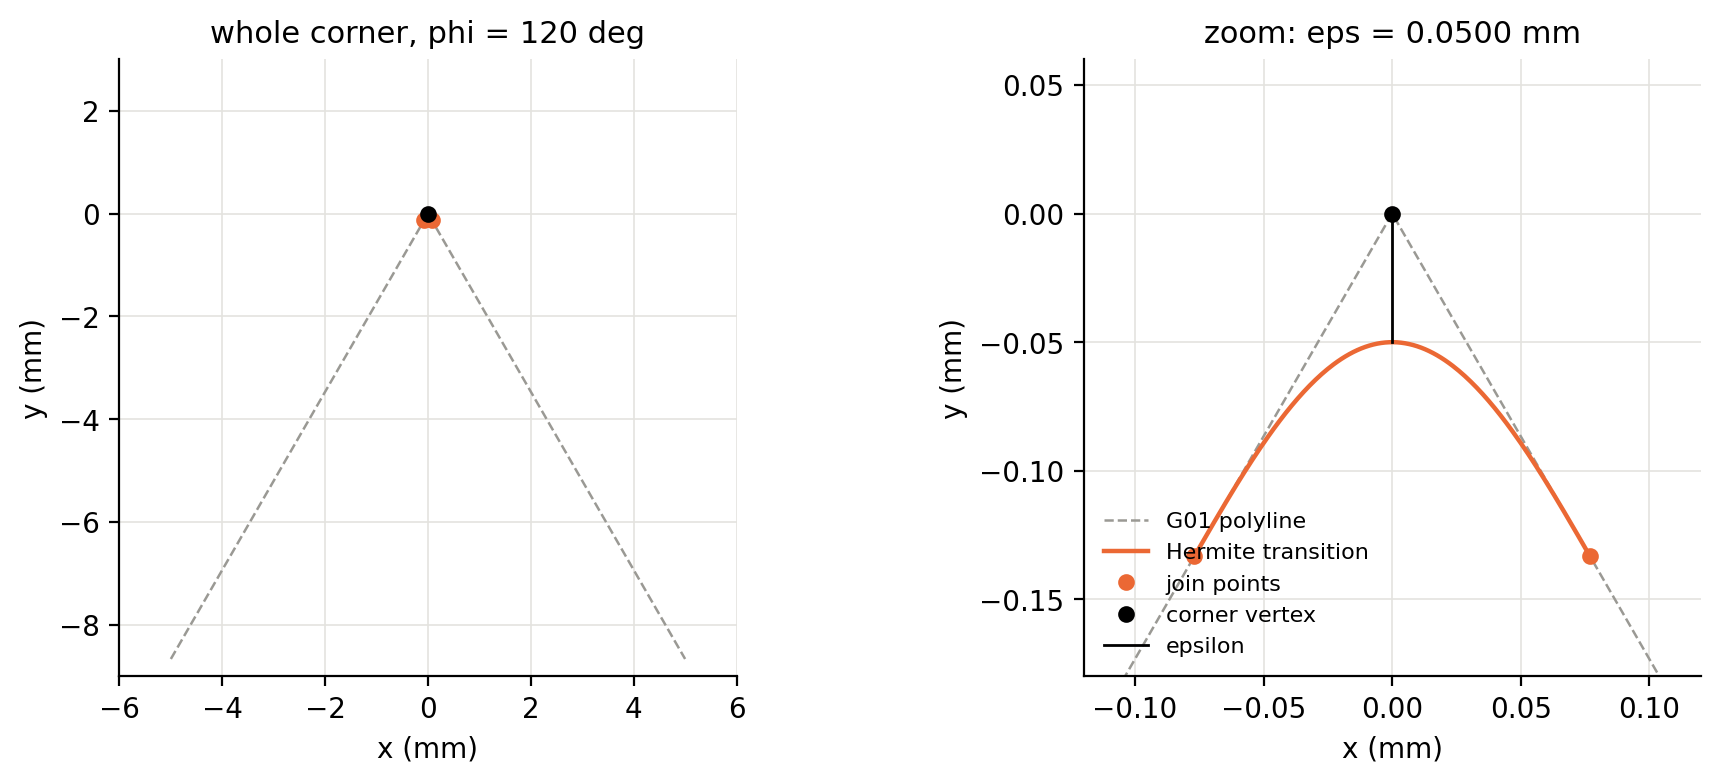

In [7]:
phi = np.deg2rad(120)
d0 = np.array([np.cos(phi / 2), np.sin(phi / 2)])
d1 = np.array([np.cos(phi / 2), -np.sin(phi / 2)])
pts3 = np.array([-10.0 * d0, np.zeros(2), 10.0 * d1])
path = cx.HermiteCornerPath(pts3, 0.05, 0.05)
curve = path.transitions[0]

cu = curve(np.linspace(0.0, 1.0, 200))
mid = curve(0.5)
ends = curve(np.array([0.0, 1.0]))

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8))
for ax, half in zip(axes, (6.0, 0.12)):
    ax.plot(pts3[:, 0], pts3[:, 1], "--", color=plotting.GRAY, lw=0.9, label="G01 polyline")
    ax.plot(cu[:, 0], cu[:, 1], color=plotting.COLORS[1], lw=1.6, label="Hermite transition")
    ax.plot(ends[:, 0], ends[:, 1], "o", ms=5, color=plotting.COLORS[1], label="join points")
    ax.plot(0, 0, "o", ms=5, color="black", label="corner vertex")
    ax.set(xlim=(-half, half), ylim=(-1.5 * half, 0.5 * half), aspect="equal", xlabel="x (mm)", ylabel="y (mm)")
axes[0].set_title("whole corner, phi = 120 deg")
axes[1].plot([0, mid[0]], [0, mid[1]], color="black", lw=1.0, label="epsilon")
axes[1].set_title(f"zoom: eps = {np.linalg.norm(mid):.4f} mm")
axes[1].legend(fontsize=8, loc="lower left")
plt.show()

左图里过渡曲线小到几乎看不见：容差 0.05 mm 只相当于 10 mm 边长的 0.5%。右图能读出三点：
过渡曲线关于角平分线对称，离顶点最近的是中点，距离正好是容差；
过渡曲线在接点处与两侧直线相切且曲率吻合（$C^2$，第 5 节有数值检查），所以接点处不需要为方向突变额外降速。
过渡是否真的比走直线快，要到第 4 节整体对比才见分晓，本节先把几何与误差确定下来。

**要点**：逼近误差 $\varepsilon$ 由裁去长度 $\ell$ 经 $\varepsilon = \tfrac38\ell\sin(\varphi/2)$
闭式控制，转角越尖，同样容差下要裁得越短；Hermite 过渡与两侧直线在接点处 $C^2$ 连续
（见第 5 节的数值检查）。

## 3. block 结构：连接点为什么放在过渡中点

光顺之后，刀具沿着"直线 + 过渡曲线"交替的轨迹走。速度规划按 block 划分：
**第 $i$ 个 block = 上一拐角过渡曲线后半段 + 中间剩下的 G01 + 下一拐角过渡曲线前半段**
（`PolylinePath.corner_blocks`，见下方打印的 block 结构）。这样每个拐角的过渡曲线被从中点
切成两半，分别属于相邻两个 block，连接点（junction）正好落在过渡中点。

为什么选过渡中点？对称过渡的**曲率峰值**就在中点。前瞻只在连接点限速，所以它应该落在
局部最难走（曲率最大）的地方；两个连接点之间的 block 内部由 S 曲线接管。这件事
butterfly 上一眼可见。

In [8]:
hermite_bf = cx.HermiteCornerPath(pts_bf, TOL, TOL)
print("前 4 个 block 的结构：")
for b in hermite_bf.blocks[:4]:
    kinds = [type(c).__name__ for c in b.curves]
    print(" ", repr(b), "curves:", kinds)
print("... 共", len(hermite_bf.blocks), "个 block，连接点", len(hermite_bf.blocks) + 1, "个")

前 4 个 block 的结构：
  Block(2 curves, length=27.192) curves: ['Line', 'SubCurve']
  Block(3 curves, length=28.7177) curves: ['SubCurve', 'Line', 'SubCurve']
  Block(3 curves, length=36.6785) curves: ['SubCurve', 'Line', 'SubCurve']
  Block(3 curves, length=40.0015) curves: ['SubCurve', 'Line', 'SubCurve']
... 共 99 个 block，连接点 100 个


打印前几个 block：第一个 block 是 [Line, SubCurve前半]（起点没有上一拐角），
中间的 block 都是 [SubCurve后半, Line, SubCurve前半]，共 99 个 block、100 个连接点。

下面看 butterfly 上一段局部（block 15–38，23 个连接点）：左图把相邻 block 交替染成
COLORS[0] 与 COLORS[1]（颜色只表示 block 交替），黑点是连接点、灰色方块是 G01 顶点；
右图是同一段上的曲率 $\kappa(s)$。过渡曲线只有零点几到几毫米长，均匀采样会漏掉尖峰，
所以在每条过渡曲线上单独加密采样。各拐角的曲率峰值相差三个数量级，纵轴取对数；
直线段上 $\kappa = 0$，在对数轴上不显示。

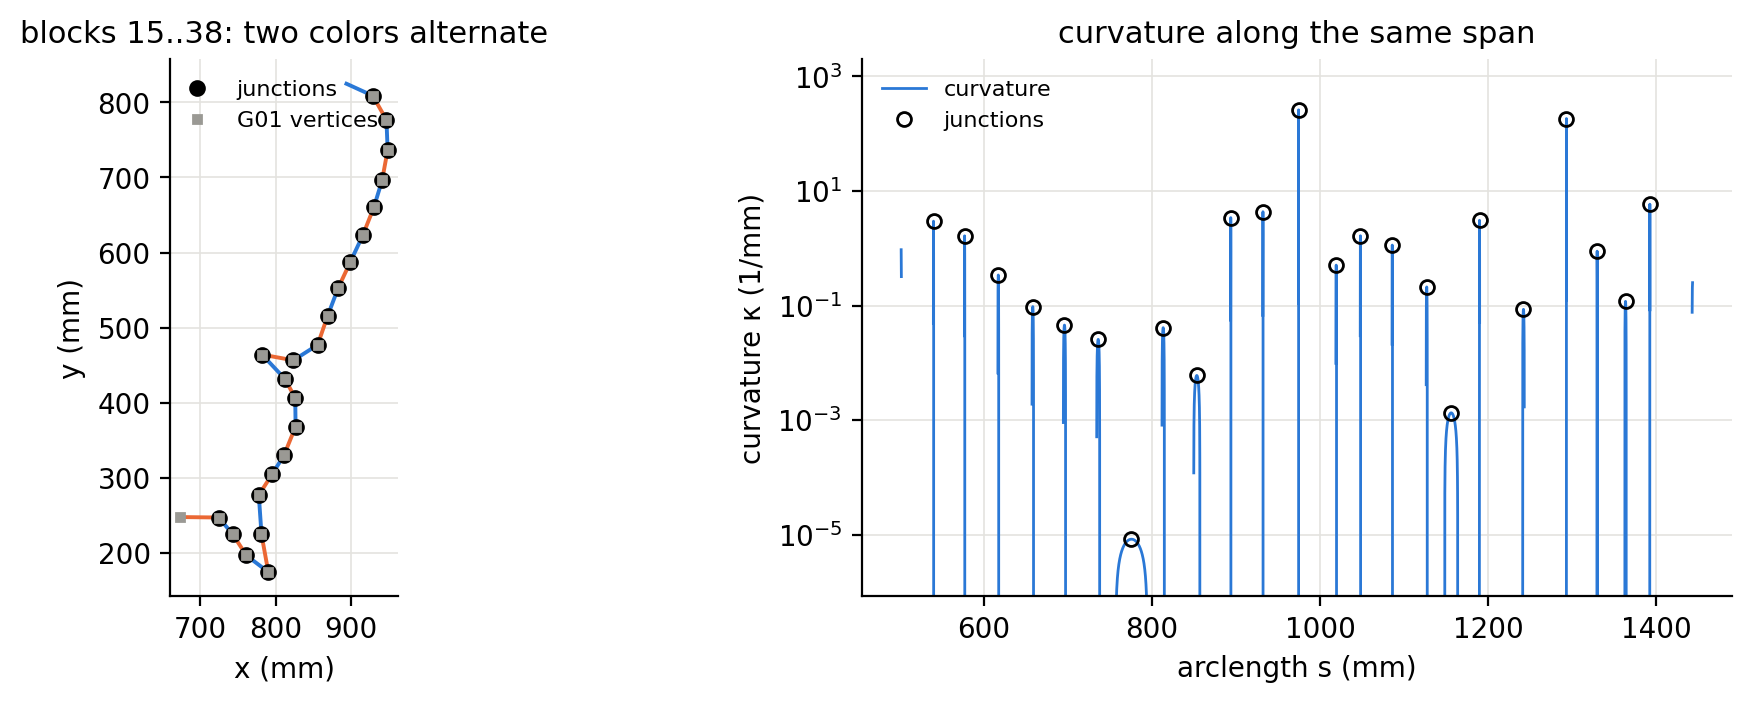

In [9]:
# 局部几段 block：交替着色 + 连接点 marker；另画 κ(s) 并标连接点
lo_i, hi_i = 15, 39  # 显示 block 15 … 38
sub_blocks = hermite_bf.blocks[lo_i:hi_i]
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))

starts = np.concatenate([[0.0], np.cumsum(hermite_bf.lengths)])
sub_lo, sub_hi = starts[lo_i], starts[hi_i]

for j in range(len(sub_blocks)):
    s0, s1 = starts[lo_i + j], starts[lo_i + j + 1]
    s_b = np.linspace(s0, s1, 400)
    d_b = hermite_bf.derivatives(s_b)
    axes[0].plot(d_b[0, :, 0], d_b[0, :, 1], color=plotting.COLORS[j % 2], lw=1.4)

s_junction = starts[lo_i + 1 : hi_i]
d_j = hermite_bf.derivatives(s_junction)
axes[0].plot(d_j[0, :, 0], d_j[0, :, 1], "o", ms=5, color="black", label="junctions")
axes[0].plot(
    pts_bf[lo_i + 1 : hi_i + 1, 0], pts_bf[lo_i + 1 : hi_i + 1, 1], "s", ms=3, color=plotting.GRAY, label="G01 vertices"
)
axes[0].set(aspect="equal", xlabel="x (mm)", ylabel="y (mm)", title="blocks 15..38: two colors alternate")
axes[0].legend(fontsize=8)

# 连接点 j 位于第 j-1 个拐角的过渡中点；在每条过渡曲线上加密采样，才不会漏掉尖峰
dense = [np.linspace(sub_lo, sub_hi, 4000)]
for j in range(lo_i + 1, hi_i):
    half_len = hermite_bf.transitions[j - 1].length / 2
    dense.append(starts[j] + np.linspace(-half_len, half_len, 201))
s = np.unique(np.concatenate(dense))
kappa = np.linalg.norm(hermite_bf.derivatives(s)[2], axis=-1)
axes[1].plot(s, np.where(kappa > 0, kappa, np.nan), color=plotting.COLORS[0], lw=1.0, label="curvature")
kappa_j = np.linalg.norm(d_j[2], axis=-1)
axes[1].plot(s_junction, kappa_j, "o", ms=5, mfc="none", color="black", label="junctions")
axes[1].set(xlabel="arclength s (mm)", ylabel="curvature κ (1/mm)", yscale="log", title="curvature along the same span")
axes[1].set_ylim(bottom=kappa_j.min() / 10)  # 过渡两端曲率趋于 0，对数轴会被拉到很低，截掉
axes[1].legend(fontsize=8)
plt.show()

**要点**：block 的分界 = 各拐角过渡的中点（曲率峰值处）。前瞻只在连接点施加限速，
而限速由该点的曲率给出（弓高误差、法向加速度、法向 jerk 三者取小，`geometric_limit`）；
block 内部由 S 曲线平滑衔接。**注意**：如果 block 内部也有曲率峰值（比如整圆、或很长而
缓慢起伏的曲率），只在连接点限速就不够，需要加连接点或换一类调度器——
见 `docs/数学约定.md` 第 3 节与 `docs/路线图.md`。

## 4. 四种方法对比：同一条流水线（butterfly）

- **G01**（`LinearPath`）：不做光顺；
- **Hermite**（`HermiteCornerPath`）：五次 Hermite 教学基线；
- **Zhao2013**（`papers.Zhao2013.algorithm.SmoothedPath`）：每拐角两段对称三次 Bézier，
  五段 S 曲线（`schedule(..., phases=5)`）；
- **Xu2018**（`papers.Xu2018.algorithm.CcrPath`）：9 控制点三次 B 样条外切圆角，七段 S 曲线。

四种刀路都走同一条流水线 `schedule → interpolate`，比较用时、最大偏离 G01 折线
（`metrics.path_deviation`：插补点到折线的最近距离，衡量拐角被"切"掉多少）、
切向加速度与 jerk 的峰值。颜色固定：G01 = COLORS[0]，Hermite = COLORS[1]，
Zhao2013 = COLORS[2]，Xu2018 = COLORS[3]。

In [10]:
from papers.Xu2018.algorithm import CcrPath
from papers.Zhao2013.algorithm import SmoothedPath

paths = {
    "G01": (linear_bf, 7),
    "Hermite": (hermite_bf, 7),
    "Zhao2013": (SmoothedPath(pts_bf, TOL), 5),
    "Xu2018": (CcrPath(pts_bf, TOL), 7),
}
colors = {
    "G01": plotting.COLORS[0],
    "Hermite": plotting.COLORS[1],
    "Zhao2013": plotting.COLORS[2],
    "Xu2018": plotting.COLORS[3],
}

In [11]:
from cnc5x import metrics

results = {}
print(f"{'method':9s} {'time (s)':>9s} {'dev-G01 (mm)':>13s} {'|a| max':>9s} {'|j| max':>9s}")
print("-" * 54)
for label, (path, phases) in paths.items():
    profile, _, _ = cx.schedule(path, V_MAX, A_MAX, J_MAX, TS, phases=phases)
    cmds = cx.interpolate(path, profile, TS)
    _, acceleration, jerk = metrics.tangential(cmds.tip)
    deviation = metrics.path_deviation(cmds.position, pts_bf).max()
    results[label] = cmds
    print(
        f"{label:9s} {cmds.t[-1]:9.3f} {deviation:13.5f} "
        f"{np.nanmax(np.abs(acceleration)):9.1f} {np.nanmax(np.abs(jerk)):9.1f}"
    )

method     time (s)  dev-G01 (mm)   |a| max   |j| max
------------------------------------------------------


G01          44.906       0.00000    2439.6   59999.4


Hermite      41.159       0.01999    2445.2   59998.7


Zhao2013     41.322       0.02000    2445.9   59998.2


Xu2018       40.783       0.01985    2439.0   59999.6


数字说明两件事：

1. **偏离 G01**：G01 为 0（它走的就是折线本身）；三种光顺都在容差 0.02 mm 附近——
   误差是被显式控制的，不是光顺的代价；
2. **用时**：G01 要 44.9 s（处处刹车起步），三种光顺在 40.8–41.3 s 之间，省约 8–9%，
   而偏离不超过容差。三种光顺之间最多差 0.54 s（约 1.3%）。

下面把四种方法的轨迹整体与局部（butterfly 上最尖的 $168^\circ$ 拐角）画在一张图上。
放大窗口取 ±0.06 mm，只有容差的三倍，否则几条曲线分不开。

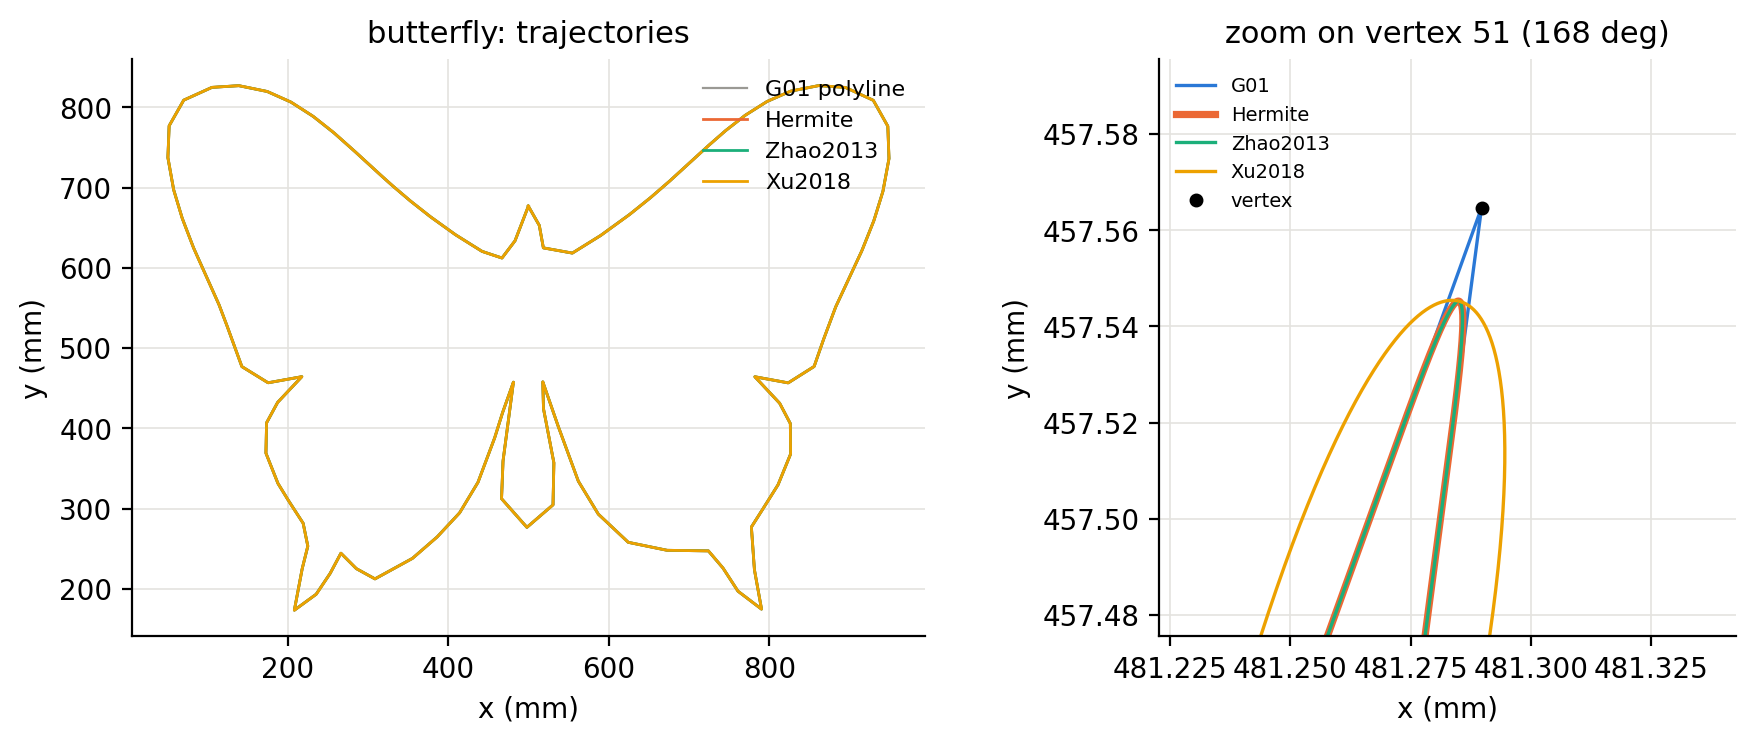

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6))
axes[0].plot(pts_bf[:, 0], pts_bf[:, 1], "-", color=plotting.GRAY, lw=0.8, label="G01 polyline")
for label in ("Hermite", "Zhao2013", "Xu2018"):
    axes[0].plot(results[label].position[:, 0], results[label].position[:, 1], lw=1.0, color=colors[label], label=label)
axes[0].set(aspect="equal", xlabel="x (mm)", ylabel="y (mm)", title="butterfly: trajectories")
axes[0].legend(fontsize=8, loc="upper right")

i_sharp = int(np.argmax(linear_bf.turning_angles))  # butterfly 上转角最大的拐角
vertex = pts_bf[i_sharp + 1]
inward = cx.unit(pts_bf[i_sharp] - vertex) + cx.unit(pts_bf[i_sharp + 2] - vertex)  # 角平分线，指向拐角内侧
center = vertex + 1.5 * TOL * cx.unit(inward)
half = 3 * TOL  # 窗口只有容差的几倍，否则几条过渡曲线分不开
for label, lw in (
    ("G01", 1.2),
    ("Hermite", 2.6),
    ("Zhao2013", 1.2),
    ("Xu2018", 1.2),
):  # Hermite 与 Zhao2013 几乎重合，画粗一点
    axes[1].plot(results[label].position[:, 0], results[label].position[:, 1], lw=lw, color=colors[label], label=label)
axes[1].plot(*vertex, "o", ms=4, color="black", label="vertex")
axes[1].set(
    xlim=(center[0] - half, center[0] + half),
    ylim=(center[1] - half, center[1] + half),
    aspect="equal",
    xlabel="x (mm)",
    ylabel="y (mm)",
    title=f"zoom on vertex {i_sharp + 1} ({np.degrees(linear_bf.turning_angles[i_sharp]):.0f} deg)",
)
axes[1].legend(fontsize=7, loc="upper left")
plt.show()

整体图上几条轨迹完全重叠，差别只有零点零几毫米。放大图里 G01（蓝）直接穿过黑色的原始顶点，
三种过渡都从顶点内侧绕过，离顶点最近处都在容差 0.02 mm 左右，形状略有不同：
Xu2018 的过渡是 B 样条外切圆角，Zhao2013 是两段三次 Bézier，Hermite 是一条五次多项式。

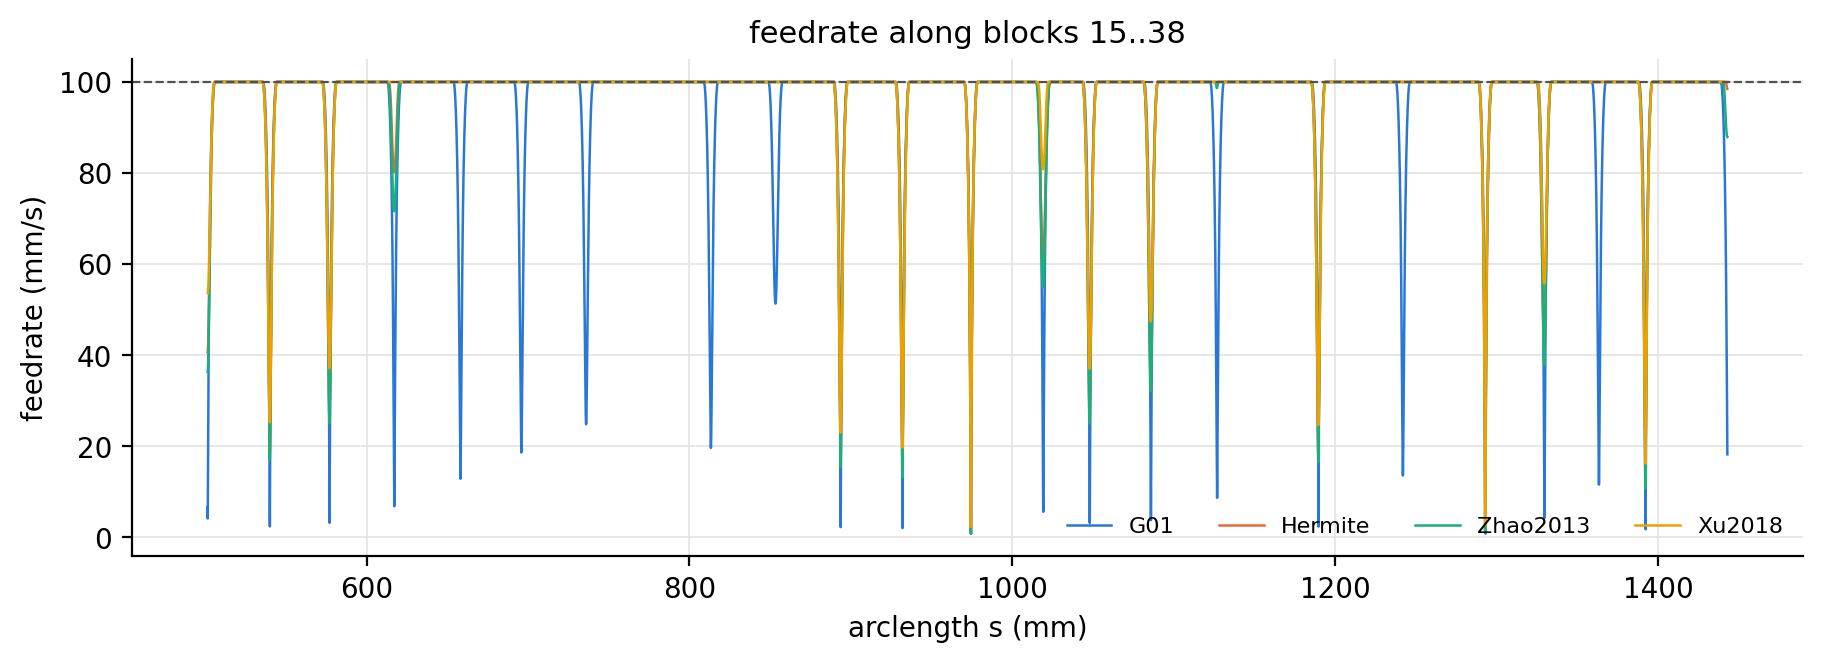

In [13]:
fig, ax = plt.subplots(figsize=(9, 3.2))
for label in ("G01", "Hermite", "Zhao2013", "Xu2018"):
    s_cmd, v_cmd = results[label].feed[0], results[label].feed[1]
    inside = (s_cmd > sub_lo) & (s_cmd < sub_hi)  # 第 3 节那一段；各刀路每个拐角只短零点零几毫米，拐角位置对得上
    ax.plot(s_cmd[inside], v_cmd[inside], lw=0.9, color=colors[label], label=label)
ax.axhline(V_MAX, color=plotting.LIMIT, ls="--", lw=0.8)
ax.set(xlabel="arclength s (mm)", ylabel="feedrate (mm/s)", title="feedrate along blocks 15..38")
ax.legend(ncols=4, fontsize=8, loc="lower right")
plt.show()

这张图只画了第 3 节那一段（block 15–38），横轴用各自刀路的弧长，四条曲线的拐角位置才能对齐。
G01（蓝）在每个拐角都要降速，转角稍大的拐角降到几 mm/s；
三种光顺方法只在转角较大的拐角有深沟，转角小的拐角几乎不减速，直边上都能达到 $v_{\max} = 100$ mm/s。
这就是拐角光顺省时间的原因：把一个方向突变换成一段可控的曲率峰值，
用不超过 $\varepsilon$ 的几何偏差换来更高的过弯速度。

## 5. 连续性检查：junction_jumps

光顺的核心承诺是**几何上的 G² 连续**。`metrics.junction_jumps(path.curves)` 检查相邻曲线段
连接处对弧长的 0、1、2 阶导数跳变，返回 $(n-1, 3)$ 三列：位置、单位切向、曲率向量的跳变。
三列都为零，路径几何就是 $C^2$（$G^2$）的。

- **位置跳变为 0**：轨迹无缺口（$G^0$）；
- **切向跳变为 0**：速度方向连续（$G^1$）——G01 在硬拐角处做不到，角越大跳变越大；
- **曲率向量跳变为 0**：加速度连续（$G^2$），法向加速度 $v^2\kappa$ 不会在接点处突然增一个量。

注意 G01 里"看似无关"的一列：直线段端点处的对弧长二阶导数严格为 0，所以 G01 的曲率向量
跳变也是 0；它的问题出在切向。

In [14]:
print(f"{'method':9s} {'n_junctions':>11s} | {'position':>9s} {'tangent':>9s} {'curvature':>10s}")
for label, (path, _) in paths.items():
    jumps = metrics.junction_jumps(path.curves)
    print(f"{label:9s} {len(jumps):11d} | {jumps[:, 0].max():9.1e} {jumps[:, 1].max():9.1e} {jumps[:, 2].max():10.1e}")

method    n_junctions |  position   tangent  curvature
G01                98 |   0.0e+00   2.0e+00    0.0e+00
Hermite           294 |   0.0e+00   3.3e-12    1.6e-10
Zhao2013          294 |   0.0e+00   2.5e-11    1.8e-07
Xu2018            294 |   0.0e+00   1.1e-11    4.0e-09


数字把两件事分得很清：

- **G01**：位置没问题（各段首尾相接），问题全在切向。最大跳变 ≈ 1.99，正好是最尖拐角
  （转角 $168^\circ$，$\beta \approx 84^\circ$）的 $2\sin\beta$。回头对照第 1 节：那个拐角只能以约 0.75 mm/s 通过。
- **三种光顺方法**：位置跳变严格为 0，切向跳变在 $10^{-11}$ 量级，曲率向量跳变最大约 $2\times10^{-7}$ 1/mm
  （Zhao2013）。这个跳变出现在曲率约 2900 1/mm 的急弯中点，相对值约 $6\times10^{-11}$，
  是浮点舍入带来的数值噪声，不是几何上的断点。

**要点**：G² 连续意味着经过接点时不存在方向或加速度的突变。junction_jumps 的
位置 / 切向 / 曲率三列分别对应 $G^0$、$G^1$、$G^2$：G01 只有第一列达标，
三种光顺方法三列同为舍入量级；G01 的切向跳变在数值上正好是 $2\sin\beta$
（下一格的 assert 会核对）。

In [15]:
tan_g01 = metrics.junction_jumps(linear_bf.curves)[:, 1]
# G01 的切向跳变应当正好是 2·sin(beta)
beta = linear_bf.turning_angles / 2
assert np.allclose(tan_g01, 2 * np.sin(beta), atol=1e-12)
print("G01 切向跳变 = 2·sin(beta)，验证通过")
for label in ("Hermite", "Zhao2013", "Xu2018"):
    jumps = metrics.junction_jumps(paths[label][0].curves)
    assert jumps.max() < 1e-5, f"{label} 未达到 G² 连续？"
print("三种光顺方法：三列跳变均 < 1e-5，G² 连续成立")

G01 切向跳变 = 2·sin(beta)，验证通过
三种光顺方法：三列跳变均 < 1e-5，G² 连续成立


## 6. 插曲：弓高限速饱和修掉了一处"停车"

连接点限速里"弓高误差"一项是

$$
v_{\text{chord}} = \frac{2}{T_s}\sqrt{2\rho\delta - \delta^2}.
$$

拐角光顺类论文把**各拐角实际的逼近误差** $\delta$ 当作弓高容差代入（Zhao2013、Xu2018 都这么做）。
关系式 $(c/2)^2 = 2\rho\delta - \delta^2$ 只在 $\delta \le \rho$ 时描述"弦长随容差增大而增大"：
$\delta = \rho$ 时弦长恰好是直径 $2\rho$；$\delta \ge 2\rho$ 时根号里为负，
**旧公式直接给出 $v = 0$**——刀具会在急弯处停车。弦长不可能超过直径，所以
`chord_error_limit` 把这一项饱和在 $2\rho/T_s$（`docs/数学约定.md` 第 3 节）。

下面用各方法的连接点曲率和实际逼近误差，对比新旧两个公式的结果。

In [16]:
from cnc5x import limits


def old_chord_limit(kappa, delta, Ts):
    """旧的（不饱和）弓高公式：κδ ≥ 2 时根号内为负，按 v = 0 处理（停车）。"""
    rho = 1 / np.where(kappa > 0, kappa, np.inf)
    val = 2 * rho * delta - delta**2
    return np.where(kappa == 0, np.inf, np.where(val > 0, 2 * np.sqrt(np.maximum(val, 0.0)) / Ts, 0.0))


zhao = paths["Zhao2013"][0]
xu = paths["Xu2018"][0]
rows = [
    ("Hermite", hermite_bf.curvature_peaks, np.full(len(hermite_bf.curvature_peaks), TOL)),
    ("Zhao2013", zhao.curvature_peaks, zhao.chord_errors),
    ("Xu2018", xu.curvature_peaks, xu.chord_errors),
]
print(f"{'method':9s} {'max κ·δ':>9s} {'old stalls':>10s} {'new min-limit':>13s}")
for label, kappa, delta in rows:
    v_old = old_chord_limit(kappa, delta, TS)
    v_new = limits.geometric_limit(kappa, delta, TS, A_MAX, J_MAX)
    print(f"{label:9s} {(kappa * delta).max():9.1f} {(v_old == 0).sum():10d} {v_new.min():13.3f}")

method      max κ·δ old stalls new min-limit
Hermite        48.6          6         0.216
Zhao2013       57.6          6         0.193
Xu2018          3.4          2         1.276


最尖的拐角处 $\kappa\delta$ 到 48–58（曲率半径只有误差的 1/50 左右），旧公式在这些点算出
$v = 0$：Zhao2013 有 6 处、Xu2018 有 2 处会无谓停车（与论文 README 里记录的对拍数据一致）。
饱和后的上限是 $2\rho/T_s$（Zhao2013 最尖拐角 $\rho \approx 3.4\times10^{-4}$ mm，
上限约 1.4 mm/s），而且这些急弯处法向加速度限速 $\sqrt{A/\kappa}$ 只有约 1 mm/s，更小——
所以饱和值一般不起作用，它只是不再让速度无谓地降到零。

**要点**：弓高公式的定义域是 $\delta \le \rho$；超出后弦长饱和在直径 $2\rho$，
限速应取 $2\rho/T_s$。公式没写成饱和形式时会"停车"，那是公式错误，不是物理结果。

## 7. 预告：五轴拐角

三轴的拐角光顺只动刀尖；五轴还要同时动**刀轴**（tool axis，由刀尖指向刀柄）。
`HermiteCornerPath` 通过
`axes` 参数支持五轴：接点处取的是 6 维刀位曲线的导数栈（`corner_ends` 含刀轴），过渡曲线
对刀尖和刀轴各做一次五次 Hermite，再把刀轴单位化，所以刀尖、刀轴对刀尖弧长都 $C^2$ 连续
（数学细节见 `docs/数学约定.md` 第 6 节）。

五轴的几何中，刀尖和刀轴的导数不能用同一个量纲相加，所以 `metrics.junction_jumps` 对五轴刀路
返回 6 列（刀尖 3 列 + 刀轴 3 列），分开检查。

In [17]:
# 五轴 Hermite：axes 参数给出每个点的单位刀轴（刀尖指向刀柄）
rng = np.random.default_rng(0)
pts_5 = rng.uniform(-10, 10, (6, 3))
axes_5 = np.array(
    [
        [0.1, 0.0, 0.995],
        [0.2, 0.0, 0.98],
        [0.3, 0.1, 0.94],
        [0.1, -0.2, 0.97],
        [-0.1, 0.1, 0.99],
        [0.0, 0.0, 1.0],
    ]
)
path_5 = cx.HermiteCornerPath(pts_5, TOL, TOL, axes=axes_5)
j5 = metrics.junction_jumps(path_5.curves)
print(f"五轴 junction_jumps 返回形状 {j5.shape}（刀尖 3 列 + 刀轴 3 列）")
print(f"刀尖列最大跳变 {j5[:, :3].max():.2e}，刀轴列最大跳变 {j5[:, 3:].max():.2e}")
assert j5.max() < 1e-6

五轴 junction_jumps 返回形状 (12, 6)（刀尖 3 列 + 刀轴 3 列）
刀尖列最大跳变 2.50e-12，刀轴列最大跳变 7.85e-14


## 练习

1. 把容差 `TOL` 改到 0.1 mm 再跑第 4 节的对比：用时是否变短？偏离折线的最大值是否仍在容差内？
   （提示：容差越大，$\ell$ 越长、曲率峰值越小。）
2. 在第 2 节的拐角验证里把 $\varphi$ 改成 $5^\circ$：实测的 $\varepsilon$ 还是
   $\tfrac38\ell\sin(\varphi/2)$ 吗？`HermiteCornerPath` 的 $\ell$ 还受什么限制（看 docstring）？
3. 用 `metrics.corner_error(vertices, cmds.position)` 替换第 4 节的 `path_deviation`，
   比较两种误差在每个拐角上的最大值：哪个更直接测量"逼近容差"？
4. 对第 4 节里的 Xu2018，检查 butterfly 上转角最大的拐角（`i_sharp`）的连接点：
   曲率峰值和该拐角的 $\varepsilon$ 是多少？用第 6 节的新旧公式，这个点会不会停车？

## 延伸阅读

- `../docs/数学约定.md`：第 3 节（block、前瞻、弓高饱和）、第 6 节（五轴拐角过渡与
  $\varepsilon$ 公式）；
- `../docs/路线图.md`：拐角光顺与五轴方向尚待做的工作；
- `../papers/Zhao2013/README.md`：Zhao et al. 2013, IJMTM, doi:10.1016/j.ijmachtools.2012.10.005；
- `../papers/Xu2018/README.md`：Xu & Sun 2018, IJAMT, doi:10.1007/s00170-017-0869-x；
- `../examples/corner_smoothing.py`：本节流水线对应的脚本版本。